# Illustrate generation of synthetic agglomerate structures

The idea is to have a very simple generator to create sufficient playground for method testing

In [1]:
import meatballsss as mbs
import numpy as np

Create meatball object which handles the grain map and orientations

Empty initialization will prompt a warning

In [2]:
agglomerate = mbs.VoxelizedMeatball()

/mnt/c/Users/sdaubner/workspace/meatballsss/meatballsss/fields.py:93: UserWarning: Empty initialization. Please generate a grain structure!
  warnings.warn("Empty initialization. Please generate a grain structure!")


Lets continue by generating a randomized structure. The function input is radius in voxels (30) and the amount of seed points (100). The particle will be padded with 5 voxels of electrolyte on each side.

In [3]:
agglomerate.create_random_agglomerate(30, 100)

The plot_slice function can be used to visualize grain structures or other associated fields in the agglomerate object. Just give the name of the field ('grains' is the default for the grain map) and the slice you would like to see. The slicing direction ('x', 'y', 'z') and colormap are optional.

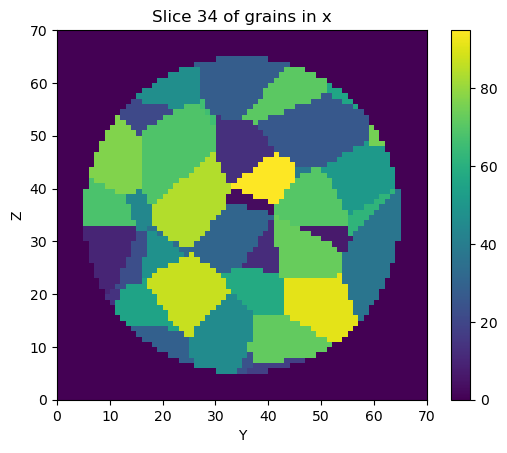

In [4]:
%matplotlib inline
agglomerate.plot_slice('grains', 34, direction='x', colormap='viridis')

There is also interactive plotting to go through the slices

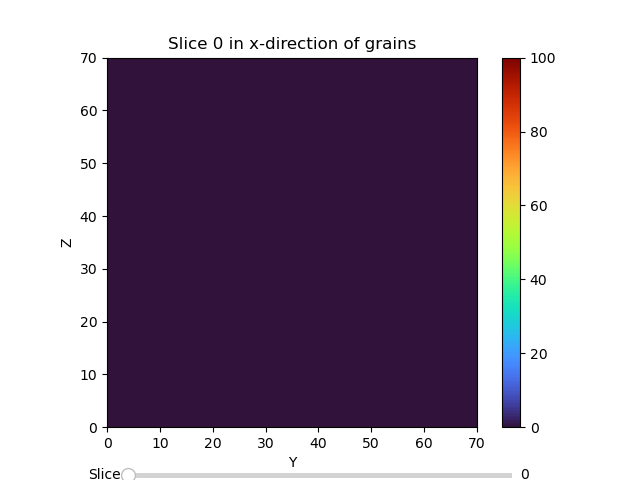

In [5]:
%matplotlib widget
agglomerate.plot_field_interactive("grains", direction='x', colormap='turbo')

### Structured agglomerate

Next is a structured agglomerate with a core-shell structure. Give as many radii as you want layers to appear.
 - radii = [10] --> particle with radius 10, all grains randomly aligned
 - radii = [20,50] --> inner core with radius 20 and randomly aligned grains, one shell with radius 50 and aligned grains
 - radii = [10,30,50] --> two shells of aligned grains and so on

In [5]:
radii = [20,50] # [20,50] #[50,80,110] #[30, 80, 100]
seed_nums = [50,100] # [50,100] #[100,150,400] #[50,300,50]

agglomerate.create_structured_agglomerate(radii, seed_nums)

/mnt/c/Users/sdaubner/workspace/meatballsss/meatballsss/fields.py:97: UserWarning: Previous grain map will be over-written!
  warnings.warn("Previous grain map will be over-written!")


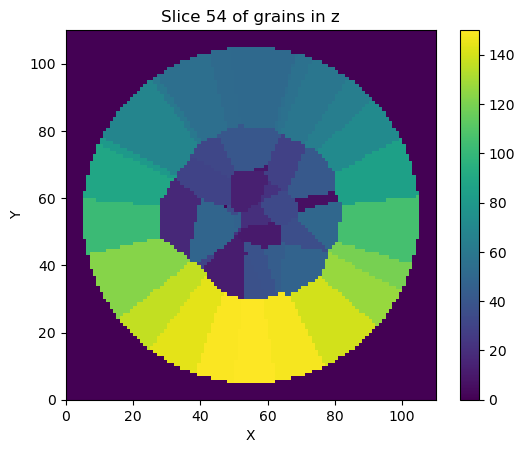

In [6]:
%matplotlib inline
agglomerate.plot_slice('grains', 54)

Explore some more comfort features of the meatball object

In [7]:
colormap = agglomerate.generate_color_map()
print(colormap.shape)
print(colormap[55,55,55])
print(np.max(colormap[:,:,:,0]))


Generating colormap from grain_map and angle_list.
(110, 110, 110, 3)
[0.52995785 0.6961933  0.32572631]
0.9879536674083254


Angles are stored as array, given in Bunge convention (ZXZ) and in degrees. phi1 and Phi are in range [0,180], phi2 in range [0,120].

In [8]:
# agglomerate.angles

We can check if the grain orientations in the synthetic agglomerate work as expected:
 - random alignment in the inner core (first 50 grains) and thus no specific alignment with radial direction
 - perfect alignment of outer shell (next 100 grains) and thus dot product of zero between c-axis and radial direction

Note: Dot products are not always perfectly zero as the orientation angles where created based on Voronoi seed points while evaluation is based on grain center of mass. They should be close but not identical.

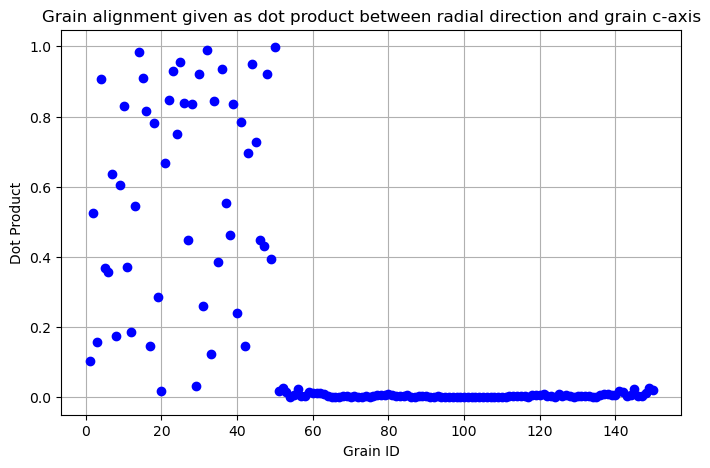

In [9]:
mbs.plot_grain_alignment(agglomerate)

### Test color augmentation on center slice

Create new meatball object from center slice of colormap

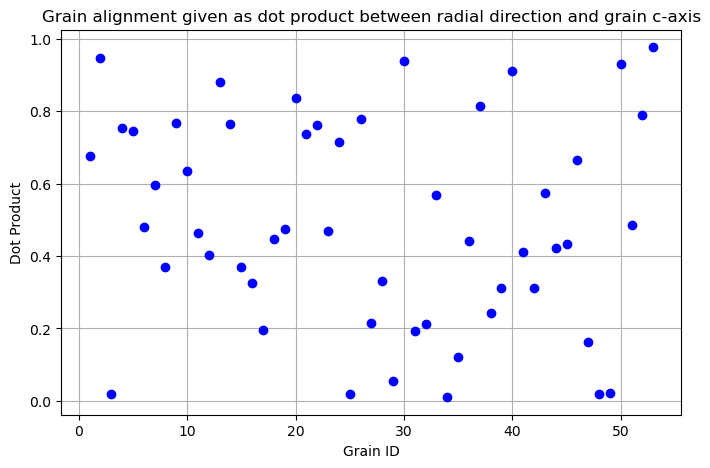

In [11]:
agglomerate2 = mbs.VoxelizedMeatball()
agglomerate2.color_array_to_grain_map(colormap[55], normalize_angles=[180,180,120])
mbs.plot_grain_alignment(agglomerate2)
dot_products2 = mbs.evaluate_grain_alignment_dot_product(agglomerate2)

Create another meatball object from modified colormap

In [49]:
color_offset = [0.5,0.0,0.1]
color_offset = np.concatenate((color_offset[0] * np.ones_like(colormap[55,:,:,0:1]), \
                               color_offset[1] * np.ones_like(colormap[55,:,:,0:1]), \
                               color_offset[2] * np.ones_like(colormap[55,:,:,0:1])), axis=2)
colormap2 = colormap[55] + color_offset
colormap2[colormap2>1] -= 1

agglomerate3 = mbs.VoxelizedMeatball()
agglomerate3.color_array_to_grain_map(colormap2, normalize_angles=[180,180,120])
dot_products3 = mbs.evaluate_grain_alignment_dot_product(agglomerate3)

Check the mean difference of dot products for the two agglomerates

In [51]:
np.mean(dot_products2-dot_products3)

0.06288008998587861

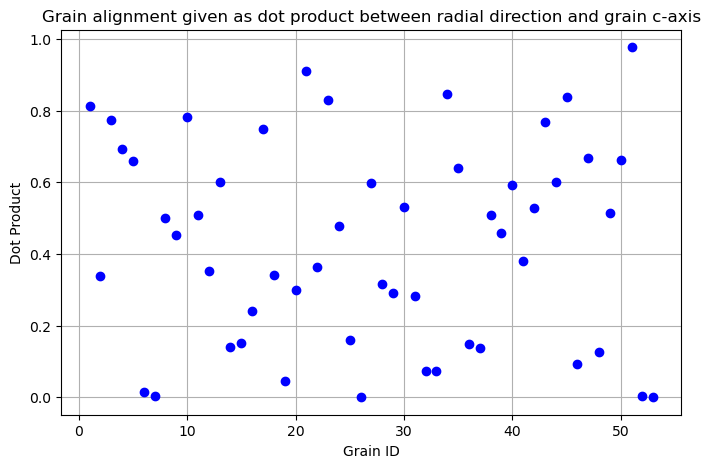

In [52]:
mbs.plot_grain_alignment(agglomerate3)

The angles can be over-written either by
 - add_random_orientations() or
 - guess_grain_orientation_from_shape() which uses PCA to find largest and smallest dimension of grain to then assign c-axis to smalles dimension (based on the assumption that c-direction grows the slowest for exagonal NMC crystals)

/mnt/c/Users/sdaubner/workspace/meatballsss/meatballsss/fields.py:172: UserWarning: Previous angles will be over-written!
  warnings.warn("Previous angles will be over-written!")


Generating random orientations...


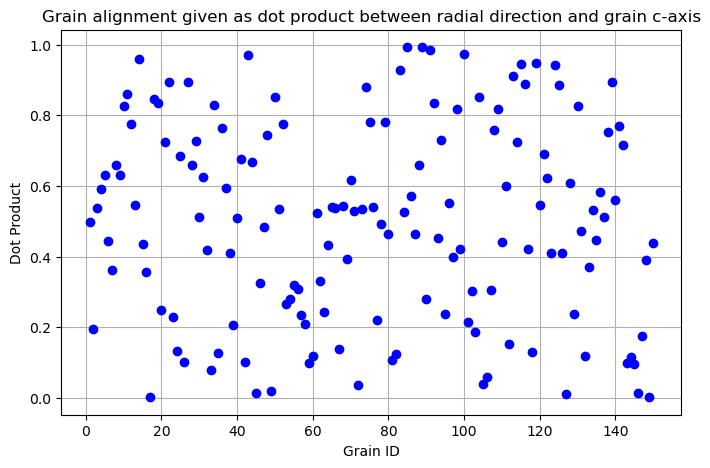

In [13]:
agglomerate.add_random_orientations()
# agglomerate.guess_grain_orientation_from_shape()
mbs.plot_grain_alignment(agglomerate)

In [ ]:
# agglomerate.relabel_random_order()

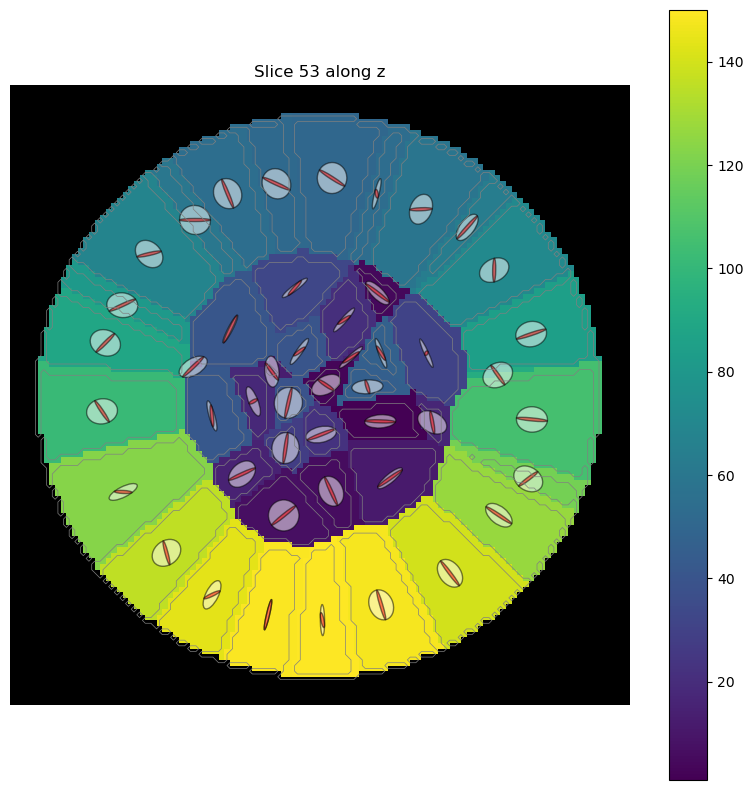

In [12]:
agglomerate.plot_slice_with_orientations(53, show_ids=False, colormap='viridis')

In [17]:
agglomerate.export_fields_to_vtk()

In [18]:
agglomerate.export_orientations_to_vtk()

In [27]:
colormap[agglomerate.fields['grains']==20][1]

array([0.98682662, 0.88065119, 0.02662583])

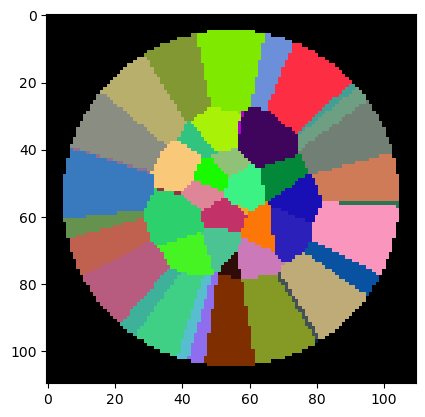

In [19]:
import matplotlib.pyplot as plt
plt.figure()
im = plt.imshow(colormap[55,:,:])

### Load color image and create grain maps

In [32]:
import meatballsss as mbs
import numpy as np
from PIL import Image

In [33]:
image = Image.open('image1050x1050.png')
# image = Image.open('image210x210.png')
image = image.convert("RGB")  # Ensure it is in RGB mode
image_array = np.array(image)

white_mask = np.all(image_array == 255, axis=-1)
# Set white pixels to black
image_array[white_mask] = [0, 0, 0]

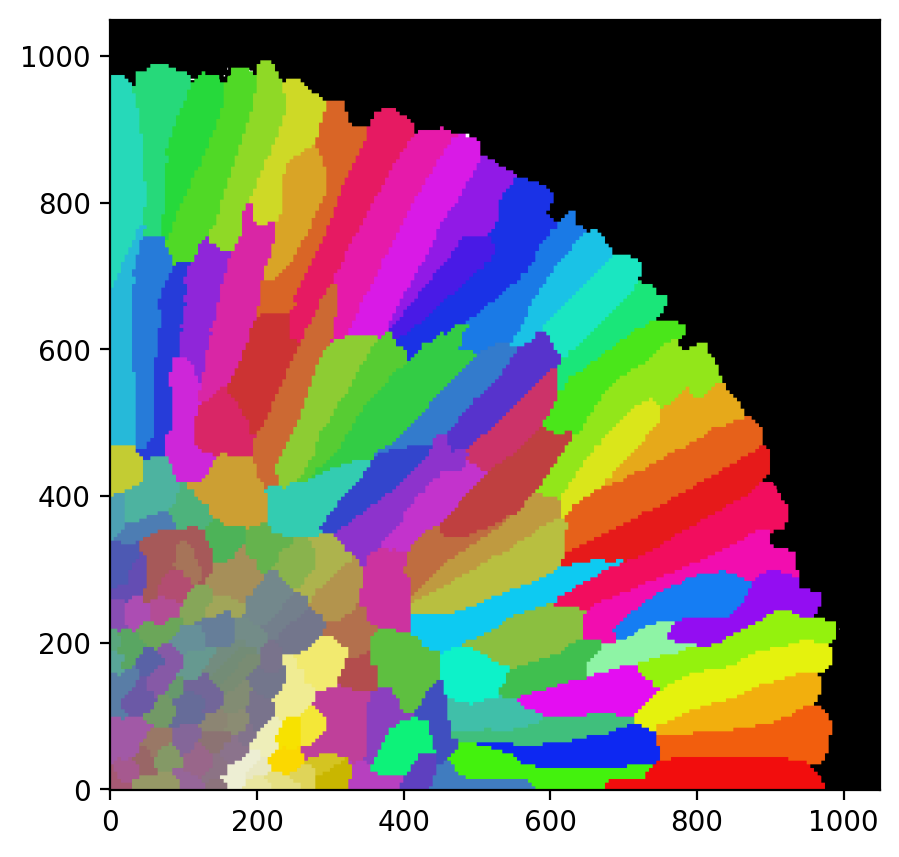

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5), dpi=200)
image_array = image_array[::-1,:,:]
# image_array = np.concatenate((image_array[:,::-1,:],image_array[::-1,::-1,:]), axis=0)
im = plt.imshow(np.transpose(image_array, (1,0,2)), origin='lower')

In [35]:
agglomerate = mbs.VoxelizedMeatball()
agglomerate.color_array_to_grain_map(image_array)

/mnt/c/Users/sdaubner/workspace/meatballsss/meatballsss/fields.py:93: UserWarning: Empty initialization. Please generate a grain structure!
  warnings.warn("Empty initialization. Please generate a grain structure!")


Generating random orientations...
Estimating grain orientations from crystal shapes!


/mnt/c/Users/sdaubner/workspace/meatballsss/meatballsss/fields.py:196: UserWarning: Previous angles will be over-written!
  warnings.warn("Previous angles will be over-written!")


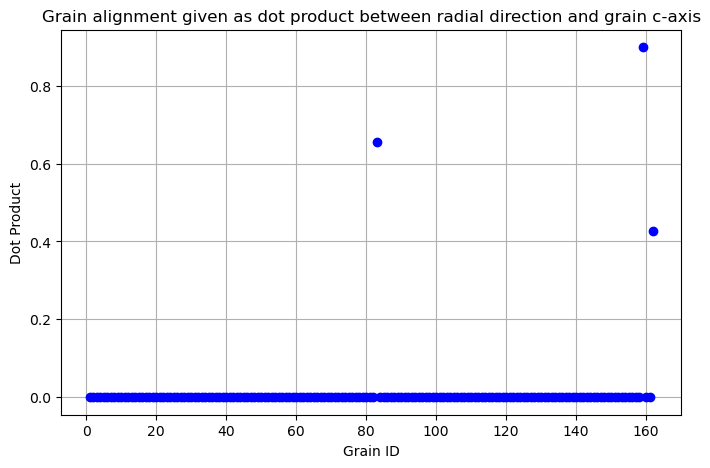

In [40]:
agglomerate.add_random_orientations()
agglomerate.guess_grain_orientation_from_shape()
mbs.plot_grain_alignment(agglomerate)

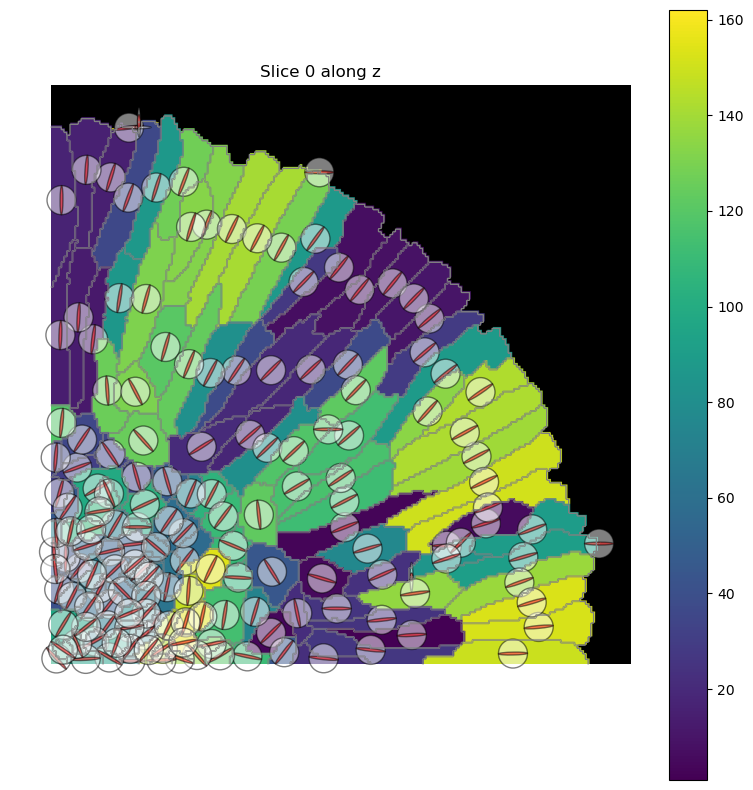

In [41]:
agglomerate.plot_slice_with_orientations(0, show_ids=False, colormap='viridis')

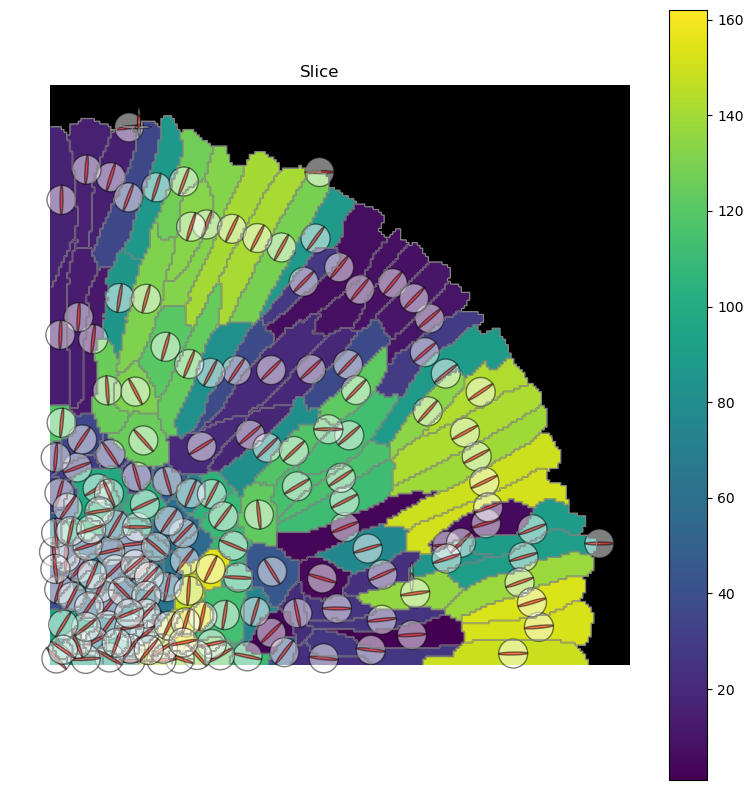

In [42]:
from scipy.spatial.transform import Rotation as rot
from matplotlib.patches import Ellipse
from skimage.segmentation import find_boundaries
from skimage.measure import find_contours

slice_img = agglomerate.fields['grains'][:,:,0]
visible_grains = np.unique(slice_img)
visible_grains = visible_grains[visible_grains != 0]
masked_slice_img = np.ma.masked_equal(slice_img, 0)
cmap = plt.get_cmap('viridis').copy()
cmap.set_bad(color='black')

boundaries = find_boundaries(slice_img, mode='inner')

plt.figure(figsize=(10, 10))
im = plt.imshow(masked_slice_img.T, cmap=cmap, origin='lower')
plt.contour(boundaries.T, colors='gray', linewidths=0.5)
plt.colorbar(im)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Slice')
ax = plt.gca()

# for grain_id in visible_grains:
#     region_mask = (slice_img == grain_id).astype(float)
#     contours = find_contours(region_mask, 0.5)
#     for contour in contours:
#         # contour[:, 0] are row indices, contour[:, 1] are column indices.
#         plt.plot(contour[:, 1], contour[:, 0], color='black', linewidth=1)

for grain_id in visible_grains:
    indices = np.argwhere(slice_img == grain_id)
    center = indices.mean(axis=0)  # center[0]: row, center[1]: column
    
    # TODO: this will fail if grain IDs are not continuous 1,2,3,4,...
    R_matrix = rot.from_euler('ZXZ', agglomerate.angles[grain_id-1], degrees=True).as_matrix()
    c_axis = R_matrix @ np.array([0, 1, 0])
    arrow = (c_axis[0], c_axis[1])
    # Compute the 3D ellipsoid axes in the global frame
    matrices = [np.diag([1, 1, 0.1]), np.diag([1, 0.1, 0.1])]
    colors = ['white', 'red']

    for i in range(2):
        ellipsoid = R_matrix @ matrices[i]
        ellipse = np.array([[1, 0, 0], [0, 1, 0]]) @ ellipsoid
        U, S, Vt = np.linalg.svd(ellipse)
        scale = (np.max([agglomerate.Nx, agglomerate.Ny, agglomerate.Nz]) / 20)
        width = S[0] * scale  # full length (major axis)
        height = S[1] * scale  # full length (minor axis)
        angle_proj = np.degrees(np.arctan2(U[1, 0], U[0, 0]))

        # Create the ellipse patch representing the projected ellipsoid.
        patch = Ellipse((center[0], center[1]), width=width, height=height,
                        angle=angle_proj, edgecolor="black", facecolor=colors[i], lw=1,\
                        alpha=0.5)
        ax.add_patch(patch)
    # plt.quiver(center[0], center[1], arrow[0], arrow[1],\
                    #    scale=40, color='red', width=0.005, pivot='middle')
    # plt.text(center[0], center[1], str(int(grain_id)), color='blue', fontsize=6, ha='center', va='center')

plt.axis('off')
plt.show()

Generating colormap from grain_map and angle_list.


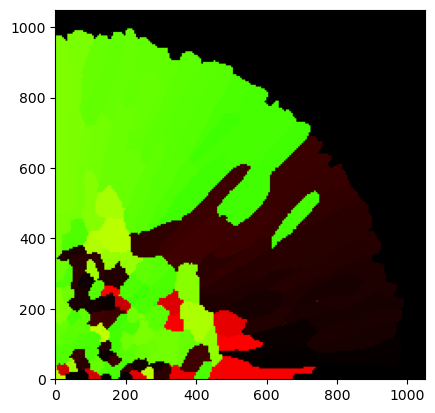

In [43]:
%matplotlib inline
# agglomerate.plot_slice('grains', 0, colormap='turbo')
colormap = agglomerate.generate_color_map()
plt.figure()
im = plt.imshow(np.transpose(colormap[:,:,0,:], (1,0,2)), origin='lower')
# im = plt.imshow(np.transpose(colormap, (1,0,2)))